## 1. Localisation du projet

On détecte automatiquement la racine du repo (le dossier qui contient `src/`), 
pour que le notebook fonctionne peu importe d'où il est lancé, et pour que les
imports depuis `src` fonctionne.

In [1]:
import sys, os
import pandas as pd

# Trouve automatiquement la racine du repo en remontant
# jusqu'à trouver un dossier contenant 'src'
RACINE_PROJET = os.getcwd()
while not os.path.isdir(os.path.join(RACINE_PROJET, "src")):
    parent = os.path.dirname(RACINE_PROJET)
    if parent == RACINE_PROJET:
        raise RuntimeError("Dossier 'src' introuvable — vérifie que tu lances "
                            "le notebook depuis un dossier à l'intérieur du repo")
    RACINE_PROJET = parent

if RACINE_PROJET not in sys.path:
    sys.path.append(RACINE_PROJET)


print("Racine du projet :", RACINE_PROJET)

Racine du projet : e:\cosit-stage-prediction-meteo


## 2. Import des bibliothèques et des modules du projet

On importe les fonctions et constantes partagées définies dans `src/` (chargement des données, préparation des features, création de la cible, et les paramètres communs comme la taille du split et le nombre de folds).

In [2]:
#Manipulation des données
import pandas as pd
import numpy as np

#Visualisation
import matplotlib.pyplot as plt
import seaborn as sns


from src.data_loading import charger_donnees
from src.features import preparer_features, creer_cible_pluie
from src.config import FEATURES_COMMUNES, TAILLE_TEST, RANDOM_STATE

## 3. Chargement des données brutes 

On charge le fichier CSV Open-Meteo (en sautant les lignes de métadonnées en en-tête), et on vérifie que le fichier a bien été trouvé et lu.

In [3]:
CHEMIN_CSV = os.path.join(RACINE_PROJET, "data", "data_OPEN_METEO.csv")
print("CSV trouvé :", os.path.exists(CHEMIN_CSV))

df = charger_donnees(CHEMIN_CSV)
df.head()


CSV trouvé : True


,time,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),wind_direction_10m_dominant (°),relative_humidity_2m_mean (%),surface_pressure_mean (hPa),cloud_cover_mean (%),sunshine_duration (s),mois
0,2015-01-01,2,29.3,24.5,26.9,0.0,0.0,0.0,17.0,34.9,215,79,1010.2,10,41319.21,1
1,2015-01-02,0,29.2,24.6,27.0,0.0,0.0,0.0,15.1,32.0,204,78,1011.0,4,41278.21,1
2,2015-01-03,3,28.9,24.7,26.9,0.0,0.0,0.0,16.7,31.3,174,83,1012.2,39,40985.12,1
3,2015-01-04,3,29.4,23.9,26.5,0.0,0.0,0.0,12.7,24.5,117,73,1012.6,15,41837.27,1
4,2015-01-05,0,29.1,23.0,25.8,0.0,0.0,0.0,12.3,24.1,91,57,1012.2,0,41934.91,1


## 4. Préparation des features 

On renomme les colonnes brutes en noms simples (humidité, pression, vent,...) et on convertit la durée d'ensoleillement de secondes en heures. Cette fonction est commune aux deux modèles du projet.

In [4]:
df = preparer_features(df)
df.head()


,time,weather_code (wmo code),temperature_2m_max (°C),temperature_2m_min (°C),temperature_2m_mean (°C),precipitation_sum (mm),rain_sum (mm),precipitation_hours (h),wind_speed_10m_max (km/h),wind_gusts_10m_max (km/h),...,surface_pressure_mean (hPa),cloud_cover_mean (%),sunshine_duration (s),mois,humidite,pression,vent_vitesse,vent_rafales,nuages,sunshine_duration_heures
0,2015-01-01,2,29.3,24.5,26.9,0.0,0.0,0.0,17.0,34.9,...,1010.2,10,41319.21,1,79,1010.2,17.0,34.9,10,11.477558
1,2015-01-02,0,29.2,24.6,27.0,0.0,0.0,0.0,15.1,32.0,...,1011.0,4,41278.21,1,78,1011.0,15.1,32.0,4,11.466169
2,2015-01-03,3,28.9,24.7,26.9,0.0,0.0,0.0,16.7,31.3,...,1012.2,39,40985.12,1,83,1012.2,16.7,31.3,39,11.384756
3,2015-01-04,3,29.4,23.9,26.5,0.0,0.0,0.0,12.7,24.5,...,1012.6,15,41837.27,1,73,1012.6,12.7,24.5,15,11.621464
4,2015-01-05,0,29.1,23.0,25.8,0.0,0.0,0.0,12.3,24.1,...,1012.2,0,41934.91,1,57,1012.2,12.3,24.1,0,11.648586


## 5. Vérification de la qualité des données

Avant de poursuivre, on vérifie l'absence de valeurs manquantes et de valeurs aberrantes dans les features utilisées.

In [5]:
print("Valeurs manquantes par colonne :")
print(df[FEATURES_COMMUNES].isna().sum())

print("\n Statistiques descriptives :")
df[FEATURES_COMMUNES].describe()

Valeurs manquantes par colonne :
humidite                    0
pression                    0
vent_vitesse                0
vent_rafales                0
nuages                      0
mois                        0
sunshine_duration_heures    0
dtype: int64

 Statistiques descriptives :


,humidite,pression,vent_vitesse,vent_rafales,nuages,mois,sunshine_duration_heures
count,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000,3653.000000
mean,82.963865,1010.526088,18.177498,34.407309,67.578976,6.522310,9.714151
std,5.033492,1.739281,3.471260,5.291037,24.984247,3.449345,2.457421
min,40.000000,1005.900000,7.300000,18.000000,0.000000,1.000000,0.000000
25%,82.000000,1009.200000,15.700000,30.600000,51.000000,4.000000,9.372911
50%,84.000000,1010.400000,17.900000,34.200000,72.000000,7.000000,10.509347
75%,86.000000,1011.800000,20.400000,37.800000,89.000000,10.000000,11.112694
max,93.000000,1016.100000,40.200000,66.600000,100.000000,12.000000,12.000000


Aucune valeur manquante ou aberrante détectée. Les données proviennent d'Open-Météo, basées sur des modèles de réanalyse (ERA5), ce qui explique l'absence de trous typiques des relevés de stations physiques.

## 6. Création de la variable cible

La cible n'existe pas directement dans le CSV : on la crée à partir de `precipitation_sum`. Un jour est considéré "pluvieux" (1) si les précipitations dépassent 1mm, sinon "non pluvieux" (0).

In [6]:
y = creer_cible_pluie(df)

X = df[FEATURES_COMMUNES]

print("Dimension de X :", X.shape)
print("Dimension de y :", y.shape)
print("Proportions de jours pluvieux :", y.mean().round(3))
X.head()

Dimension de X : (3653, 7)
Dimension de y : (3653,)
Proportions de jours pluvieux : 0.508


,humidite,pression,vent_vitesse,vent_rafales,nuages,mois,sunshine_duration_heures
0,79,1010.2,17.0,34.9,10,1,11.477558
1,78,1011.0,15.1,32.0,4,1,11.466169
2,83,1012.2,16.7,31.3,39,1,11.384756
3,73,1012.6,12.7,24.5,15,1,11.621464
4,57,1012.2,12.3,24.1,0,1,11.648586


## 7. Répartition entraînement/test

On sépare les données en un jeu d'entraînement (80%) et un jeu de test (20%), 
mis de côté et non utilisé avant l'utilisation finale. La stratification garantit que la proportion de jours pluvieux reste similaire dans les deux jeux, malgré le déséquilibre des classes.

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TAILLE_TEST,
    random_state=RANDOM_STATE,
    stratify=y  # utile ici car classes déséquilibrées (jours secs vs pluvieux)
)

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Proportion de pluie (train) :", y_train.mean().round(3))
print("Proportion de pluie (test) :", y_test.mean().round(3))

Train : (2922, 7) | Test : (731, 7)
Proportion de pluie (train) : 0.508
Proportion de pluie (test) : 0.508


## 8. Modèle 1 - Régression logistique (modèle de référence)

On entraîne un modèle simple et interprétable comme point de comparaison pour les modèles suivants (Random Forest, Gradient Boosting). On l'entraîne directement sur le train set, sans recherche d'hyperparamètres complexe, puisque c'est notre référence de base.

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

modele_logit = LogisticRegression(random_state= RANDOM_STATE, max_iter= 1000)
modele_logit.fit(X_train, y_train)

y_pred_logit = modele_logit.predict(X_test)

print("=== Régression logistique ===")
print(classification_report(y_test, y_pred_logit))

=== Régression logistique ===
              precision    recall  f1-score   support

           0       0.70      0.70      0.70       360
           1       0.71      0.71      0.71       371

    accuracy                           0.71       731
   macro avg       0.71      0.71      0.71       731
weighted avg       0.71      0.71      0.71       731



## 9.  Stockage des métriques pour comparaison finale

On garde les métriques de chaque modèle dans un tableau, pour pouvoir comparer les trois modèles côte à côte à la fin, comme convenu pour le raport.

In [9]:
resultats = []

resultats.append({
    "modele": "Régression logistique",
    "precision" : precision_score(y_test, y_pred_logit),
    "rappel" : recall_score(y_test, y_pred_logit),
    "f1" : f1_score(y_test, y_pred_logit)
})

pd.DataFrame(resultats)

,modele,precision,rappel,f1
0,Régression logistique,0.709677,0.71159,0.710633


## 10. Validation croisée

In [10]:
from sklearn.model_selection import cross_val_score

scores_cv_logit = cross_val_score(
    LogisticRegression(random_state= RANDOM_STATE, max_iter= 1000),
    X_train, y_train,
    cv=5,
    scoring="f1"
)

print("F1 par fold :", scores_cv_logit.round(3))
print("F1 moyen(CV)", scores_cv_logit.mean().round(3))

F1 par fold : [0.701 0.699 0.734 0.716 0.725]
F1 moyen(CV) 0.715


## 11. Modèle 2 - Random Forest Classificator

Méthode ensembliste par bagging. On utilise RandomizedSearchCV pour explorer un espace d'hyperparamètres et trouver la meilleure combinaison, avec validation croisée à 5 folds sur le train set uniquement.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

grille_rf ={
    "n_estimators": [100, 200, 300, 500],
    "max_depth":   [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}
rf_search = RandomizedSearchCV(
    estimator= RandomForestClassifier(random_state= RANDOM_STATE),
    param_distributions= grille_rf,
    n_iter= 30,
    cv= 5,
    scoring= "f1",
    random_state= RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres RF:", rf_search.best_params_)
modele_rf = rf_search.best_estimator_

Meilleurs hyperparamètres RF: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': None}


## 12. Evaluation du Random Forest Classificator sur le test set

In [12]:
y_pred_rf = modele_rf.predict(X_test)

print("===  Random Forest ===")
print(classification_report(y_test, y_pred_rf))

resultats.append({
    "modele": "Random Forest",
    "precision": precision_score(y_test, y_pred_rf),
    "rappel": recall_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
})

pd.DataFrame(resultats)

===  Random Forest ===
              precision    recall  f1-score   support

           0       0.74      0.71      0.73       360
           1       0.73      0.76      0.75       371

    accuracy                           0.74       731
   macro avg       0.74      0.74      0.74       731
weighted avg       0.74      0.74      0.74       731



,modele,precision,rappel,f1
0,Régression logistique,0.709677,0.711590,0.710633
1,Random Forest,0.730570,0.760108,0.745046


## 13. Modèle 3 — Gradient Boosting Classifier

Méthode ensembliste par boosting. Comme pour le Random Forest, on utilise 
RandomizedSearchCV avec validation croisée à 5 folds pour trouver les 
meilleurs hyperparamètres sur le train set.

In [13]:
from sklearn.ensemble import GradientBoostingClassifier

grille_gb = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "max_depth": [2, 3, 4, 5],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "subsample": [0.8, 0.9, 1.0],
}

gb_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=grille_gb,
    n_iter=30,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

gb_search.fit(X_train, y_train)

print("Meilleurs hyperparamètres GB :", gb_search.best_params_)
modele_gb = gb_search.best_estimator_

Meilleurs hyperparamètres GB : {'subsample': 0.9, 'n_estimators': 100, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 3, 'learning_rate': 0.05}


## 14. Évaluation du Gradient Boosting sur le test set

In [14]:
y_pred_gb = modele_gb.predict(X_test)

print("=== Gradient Boosting ===")
print(classification_report(y_test, y_pred_gb))

resultats.append({
    "modele": "Gradient Boosting",
    "precision": precision_score(y_test, y_pred_gb),
    "rappel": recall_score(y_test, y_pred_gb),
    "f1": f1_score(y_test, y_pred_gb),
})

pd.DataFrame(resultats)

=== Gradient Boosting ===
              precision    recall  f1-score   support

           0       0.74      0.71      0.72       360
           1       0.73      0.76      0.74       371

    accuracy                           0.73       731
   macro avg       0.73      0.73      0.73       731
weighted avg       0.73      0.73      0.73       731



,modele,precision,rappel,f1
0,Régression logistique,0.709677,0.711590,0.710633
1,Random Forest,0.730570,0.760108,0.745046
2,Gradient Boosting,0.727979,0.757412,0.742404


## Matrices de confusion — comparaison des 3 modèles

On visualise, pour chaque modèle, la répartition entre vrais positifs, 
vrais négatifs, faux positifs et faux négatifs, afin de mieux comprendre 
le type d'erreur commis par chacun.

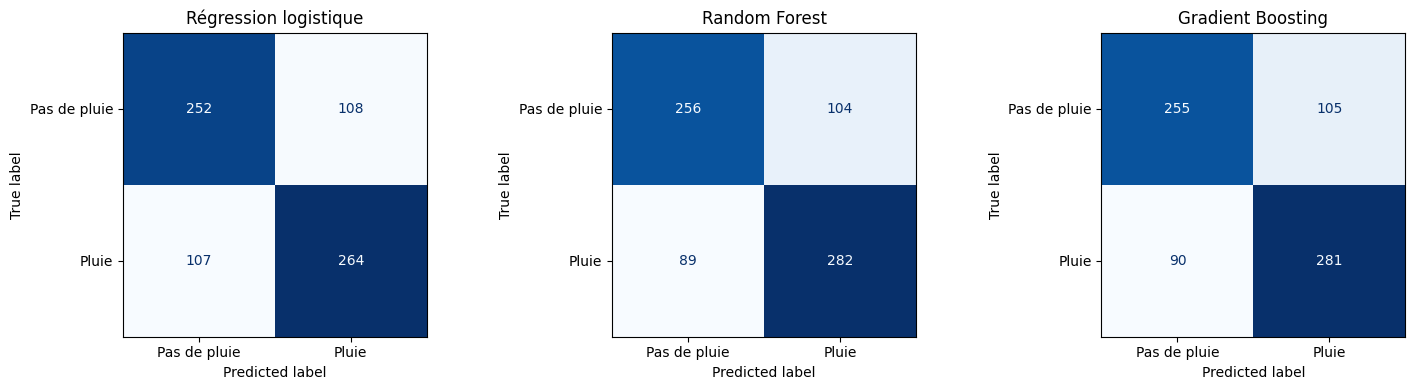

In [16]:


fig, axes = plt.subplots(1, 3, figsize=(15, 4))

predictions = {
    "Régression logistique": y_pred_logit,
    "Random Forest": y_pred_rf,
    "Gradient Boosting": y_pred_gb,
}

for ax, (nom_modele, y_pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Pas de pluie", "Pluie"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(nom_modele)

plt.tight_layout()
plt.show()

## Tentative d'optimisation : affinage des hyperparamètres

Après avoir comparé les 3 modèles sur leurs paramètres initiaux, on tente d'améliorer encore les deux modèles ensemblistes (RandomForest et Gradient Boosting) en resserrant la recherche d'hyperparamaètres autour des meilleures valeures déjà trouvées.

## Random Forest

In [17]:
grille_rf_affinee = {
    "n_estimators": [150, 200, 250, 300],
    "max_depth": [None, 20, 25, 30],
    "min_samples_split": [2, 3, 4],
    "min_samples_leaf": [2, 3, 4, 5],
    "max_features": ["sqrt", 0.3, 0.5],
}

rf_search2 = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=grille_rf_affinee,
    n_iter=40,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_search2.fit(X_train, y_train)
print("Nouveaux meilleurs hyperparamètres RF :", rf_search2.best_params_)

Nouveaux meilleurs hyperparamètres RF : {'n_estimators': 250, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 30}


## Gradient Boosting

In [18]:
grille_gb_affinee = {
    "n_estimators": [80, 100, 150, 200],
    "learning_rate": [0.03, 0.05, 0.07, 0.1],
    "max_depth": [2, 3, 4],
    "min_samples_split": [5, 10, 15],
    "min_samples_leaf": [2, 4, 6],
    "subsample": [0.8, 0.85, 0.9, 0.95],
}

gb_search2 = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=RANDOM_STATE),
    param_distributions=grille_gb_affinee,
    n_iter=40,
    cv=5,
    scoring="f1",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
gb_search2.fit(X_train, y_train)
print("Nouveaux meilleurs hyperparamètres GB :", gb_search2.best_params_)

Nouveaux meilleurs hyperparamètres GB : {'subsample': 0.8, 'n_estimators': 80, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_depth': 4, 'learning_rate': 0.05}


In [22]:
y_pred_rf2 = rf_search2.best_estimator_.predict(X_test)
y_pred_gb2 = gb_search2.best_estimator_.predict(X_test)

print("=== RF affiné ===")
print(classification_report(y_test, y_pred_rf2))

print("\n=== GB affiné ===")
print(classification_report(y_test, y_pred_gb2))

=== RF affiné ===
              precision    recall  f1-score   support

           0       0.74      0.70      0.72       360
           1       0.72      0.76      0.74       371

    accuracy                           0.73       731
   macro avg       0.73      0.73      0.73       731
weighted avg       0.73      0.73      0.73       731


=== GB affiné ===
              precision    recall  f1-score   support

           0       0.74      0.71      0.72       360
           1       0.73      0.76      0.74       371

    accuracy                           0.73       731
   macro avg       0.73      0.73      0.73       731
weighted avg       0.73      0.73      0.73       731



## Comparaison visuelle : hyperparamètres originaux vs affinés

Visualisation des scores F1 avant/après l'affinage des hyperparamètres, 
pour le Random Forest et le Gradient Boosting.

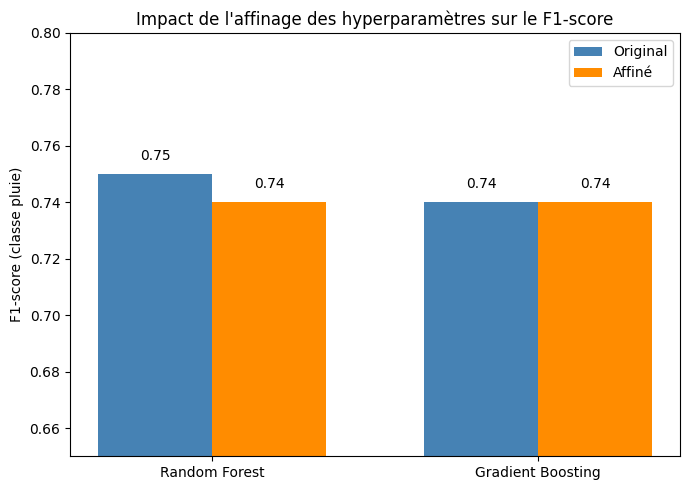

In [24]:
comparaison_affinage = pd.DataFrame({
    "modele": ["Random Forest", "Random Forest", "Gradient Boosting", "Gradient Boosting"],
    "version": ["Original", "Affiné", "Original", "Affiné"],
    "f1": [0.75, 0.74, 0.74, 0.74],  # F1 de la classe "pluie" (1)
})

fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(2)  # 2 modèles
largeur = 0.35

f1_original = comparaison_affinage[comparaison_affinage["version"] == "Original"]["f1"].values
f1_affine = comparaison_affinage[comparaison_affinage["version"] == "Affiné"]["f1"].values

ax.bar(x - largeur/2, f1_original, largeur, label="Original", color="steelblue")
ax.bar(x + largeur/2, f1_affine, largeur, label="Affiné", color="darkorange")

ax.set_xticks(x)
ax.set_xticklabels(["Random Forest", "Gradient Boosting"])
ax.set_ylabel("F1-score (classe pluie)")
ax.set_ylim(0.65, 0.80)
ax.set_title("Impact de l'affinage des hyperparamètres sur le F1-score")
ax.legend()

for i, (orig, aff) in enumerate(zip(f1_original, f1_affine)):
    ax.text(i - largeur/2, orig + 0.005, f"{orig:.2f}", ha="center")
    ax.text(i + largeur/2, aff + 0.005, f"{aff:.2f}", ha="center")

plt.tight_layout()
plt.show()

## Conclusion sur l'affinage des hyperparamètres

Un second passage de `RandomizedSearchCV`, avec une grille resserrée autour 
des premiers hyperparamètres optimaux, n'a pas amélioré les performances 
des modèles — le Random Forest affiné obtient même des scores légèrement 
inférieurs à sa première version (F1 pluie : 0.74 contre 0.75), et le 
Gradient Boosting reste quasiment inchangé.

Ce plateau suggère que la limite de performance actuelle provient des 
données et des features disponibles, plutôt que d'un mauvais réglage des 
hyperparamètres. Les modèles issus de la première recherche 
(`RandomizedSearchCV` sur grille large) sont donc conservés comme modèles 
finaux, sans passage supplémentaire par `GridSearchCV`.

## Importance des features (Random Forest — modèle final)

On visualise quelles variables météo influencent le plus les prédictions 
du modèle retenu, pour mieux interpréter son fonctionnement.

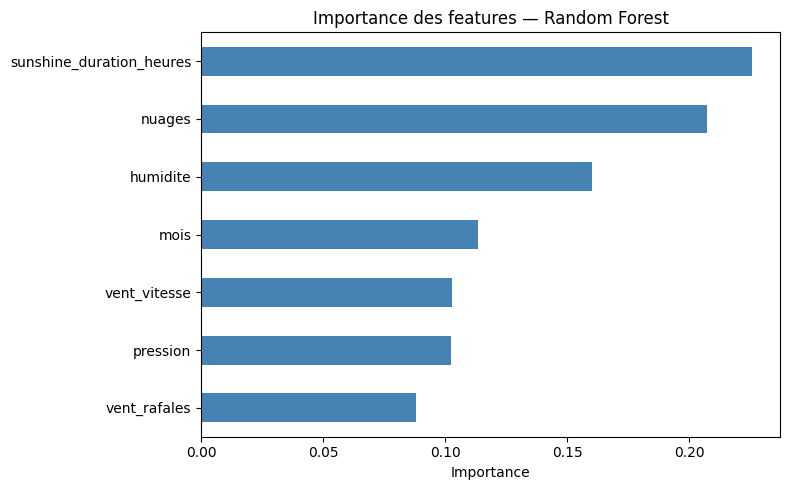

sunshine_duration_heures    0.225800
nuages                      0.207175
humidite                    0.160187
mois                        0.113548
vent_vitesse                0.102758
pression                    0.102363
vent_rafales                0.088170
dtype: float64

In [29]:

importances = pd.Series(modele_rf.feature_importances_, index=FEATURES_COMMUNES)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("Importance des features — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances

In [30]:
"""

     
"""

'\n\n\n'